In [81]:
import torch
from torch import nn
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

In [82]:
#writing device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [83]:
#create a binary dataset with sklearn
n_samples= 1000
random_state=42

x,y = make_moons(n_samples,shuffle=True,
                 noise=0.1,
                 random_state=random_state)
#turn the data into tensors
x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

x[:10],y[:10]

(tensor([[-0.0515,  0.4442],
         [ 1.0320, -0.4197],
         [ 0.8679, -0.2548],
         [ 0.2889, -0.4487],
         [-0.8334,  0.5351],
         [ 0.6137, -0.2424],
         [ 0.2865, -0.2013],
         [-0.0561,  0.4771],
         [ 1.6042, -0.3035],
         [ 0.7096,  0.8589]]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

In [84]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=random_state)

len(x_train),len(x_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [85]:
#lets put the data in a dataframe to visualize
import pandas as pd

df = pd.DataFrame({"X1":x[:,0],"X2":x[:,1],"Labels":y[:]})
df.head(10)

,X1,X2,Labels
0,-0.051470,0.444199,1.0
1,1.032017,-0.419741,1.0
2,0.867892,-0.254827,1.0
3,0.288851,-0.448669,1.0
4,-0.833439,0.535057,0.0
5,0.613706,-0.242369,1.0
6,0.286495,-0.201277,1.0
7,-0.056104,0.477079,1.0
8,1.604217,-0.303541,1.0
9,0.709642,0.858867,0.0


In [86]:
#lets check the different labels
df.Labels.value_counts()

,count
Labels,
1.0,500
0.0,500


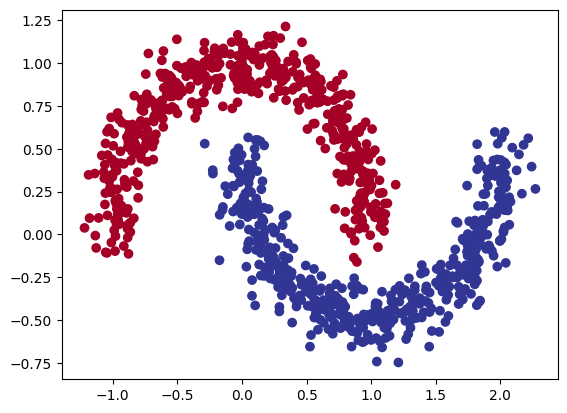

In [87]:
#lets visualize the plot
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.RdYlBu);



In [88]:
#lets check the input and output shapes
x.shape , y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [89]:
#lets instanciate the instance of nn.Module

class make_moon_model(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2,out_features=10)
    self.layer2 = nn.Linear(in_features=10, out_features=10)
    self.layer3= nn.Linear(in_features=10,out_features=10)
    self.layer4 = nn.Linear(in_features=10,out_features=1)


    self.relu = nn.ReLU()

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return self.layer4(self.relu(self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))))

#instantiate the instance of out model and put inside the device
moon_model = make_moon_model().to(device)





In [90]:
#lets create loss function and optimizer and accuracy
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=moon_model.parameters(),
                           lr=0.1)

def accuracy(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  return (correct/len(y_pred))*100

In [91]:
#now time to create a training loop

torch.manual_seed(42)

#put the data into same device as model
x_train, y_train = x_train.to(device),y_train.to(device)
x_test,y_test= x_test.to(device),y_test.to(device)

epochs = 1000

for epoch in range(epochs):
  #train mode
  moon_model.train()

  #forward function
  y_logits = moon_model(x_train)
  y_preds = torch.round(torch.sigmoid(y_logits))

  #calculate loss and accuracy
  loss = loss_fn(y_logits,y_train.unsqueeze(dim=1))
  train_accuracy = accuracy(y_train,y_preds.squeeze()) # Renamed variable to avoid shadowing function

  #optimize zero grad
  optimizer.zero_grad()

  #loss backwards
  loss.backward()

  #optimize the model
  optimizer.step()

  #evaluate the model
  moon_model.eval()
  with torch.inference_mode():
    test_logits = moon_model(x_test)
    test_preds = torch.round(torch.sigmoid(test_logits))

    #calculate the loss and accuracy
    test_loss = loss_fn(test_logits,y_test.unsqueeze(dim=1))
    test_accuracy = accuracy(y_test,test_preds.squeeze()) # Renamed variable to avoid shadowing function

    #print the train and test loss as well as accuracy
    if epoch %10 ==0:
      print(f"Epoch:{epoch} | train_loss:{loss:.4f} | train_accuracy:{train_accuracy:.4f}%| test_loss:{test_loss:.4f}| test_accuracy:{test_accuracy:.4f}%")

Epoch:0 | train_loss:0.6981 | train_accuracy:50.0000%| test_loss:0.6969| test_accuracy:50.0000%
Epoch:10 | train_loss:0.6938 | train_accuracy:50.0000%| test_loss:0.6928| test_accuracy:50.0000%
Epoch:20 | train_loss:0.6905 | train_accuracy:50.0000%| test_loss:0.6896| test_accuracy:50.0000%
Epoch:30 | train_loss:0.6872 | train_accuracy:50.0000%| test_loss:0.6864| test_accuracy:50.0000%
Epoch:40 | train_loss:0.6833 | train_accuracy:50.0000%| test_loss:0.6827| test_accuracy:50.0000%
Epoch:50 | train_loss:0.6784 | train_accuracy:54.6250%| test_loss:0.6779| test_accuracy:58.5000%
Epoch:60 | train_loss:0.6717 | train_accuracy:89.0000%| test_loss:0.6713| test_accuracy:88.0000%
Epoch:70 | train_loss:0.6620 | train_accuracy:86.5000%| test_loss:0.6618| test_accuracy:84.5000%
Epoch:80 | train_loss:0.6487 | train_accuracy:81.8750%| test_loss:0.6488| test_accuracy:78.0000%
Epoch:90 | train_loss:0.6307 | train_accuracy:80.5000%| test_loss:0.6308| test_accuracy:80.0000%
Epoch:100 | train_loss:0.6051 |

In [92]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

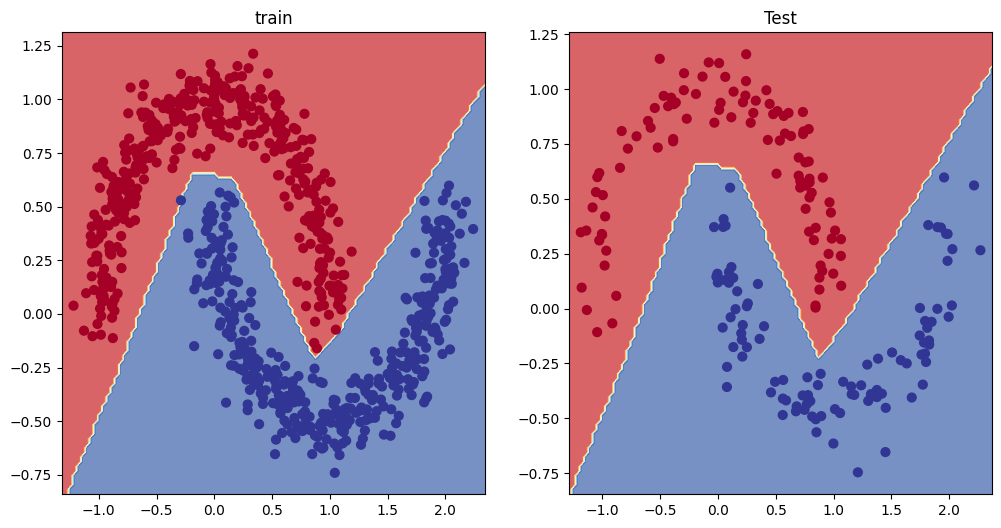

In [93]:
#making predictions with new trained model

moon_model.eval()
with torch.inference_mode():
  y_logits_new = moon_model(x_test)
  y_preds_new = torch.round(torch.sigmoid(y_logits_new))


#lets plot decision boundary for training and test set
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(moon_model,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(moon_model,x_test,y_test)

